 # Diabetes Prediction - Improved Analysis

 Dataset: Diabetes Prediction (Usia Produktif 18-45 tahun)

 Semua fitur digunakan untuk analisis

In [1272]:
import pandas as pd
import seaborn as sns
import warnings
import matplotlib.pyplot as plt
import numpy as np
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, auc, classification_report,
                             confusion_matrix, f1_score, precision_score,
                             recall_score, roc_auc_score, roc_curve)
from sklearn.model_selection import (StratifiedKFold, cross_val_score,
                                     train_test_split)
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')

# Set style untuk visualisasi
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)


 ## 1. Load dan Eksplorasi Data

In [1273]:
# Load dataset
df = pd.read_csv("../data/diabetes_binary_health_indicators_BRFSS2015.csv")
df = df.rename(columns={'Diabetes_binary': 'diabetes'})
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print("Shape dataset awal:", df.shape)
print("\n5 baris pertama:")
df.head(30)


Shape dataset awal: (253680, 22)

5 baris pertama:


,diabetes,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0
5,0.0,1.0,1.0,1.0,25.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,2.0,0.0,1.0,10.0,6.0,8.0
6,0.0,1.0,0.0,1.0,30.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0,0.0,14.0,0.0,0.0,9.0,6.0,7.0
7,0.0,1.0,1.0,1.0,25.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,3.0,0.0,0.0,1.0,0.0,11.0,4.0,4.0
8,1.0,1.0,1.0,1.0,30.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,5.0,30.0,30.0,1.0,0.0,9.0,5.0,1.0
9,0.0,0.0,0.0,1.0,24.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,1.0,8.0,4.0,3.0


In [1274]:
print("Informasi Dataset:")
df.info()


Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   diabetes              253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-

In [1275]:
print("Statistik Deskriptif:")
df.describe()


Statistik Deskriptif:


,diabetes,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.139333,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,0.634256,0.811420,0.056197,0.951053,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875
std,0.346294,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,0.481639,0.391175,0.230302,0.215759,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,0.000000,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,0.000000,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,1.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


In [1276]:
print("Missing Values:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")


Missing Values:
diabetes                0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

Total missing values: 0


In [1277]:
print(f"Jumlah duplikat: {df.duplicated().sum()}")


Jumlah duplikat: 24206


In [1278]:
print("Distribusi Target Variable:")
print(df['diabetes'].value_counts())
print("\nPersentase:")
print(df['diabetes'].value_counts(normalize=True) * 100)


Distribusi Target Variable:
diabetes
0.0    218334
1.0     35346
Name: count, dtype: int64

Persentase:
diabetes
0.0    86.066698
1.0    13.933302
Name: proportion, dtype: float64


 ## 2. Data Preprocessing

In [1279]:
# Filter usia produktif (18-45 tahun) sesuai fokus penelitian
print(f"Data sebelum filter usia: {df.shape}")
df = df[df['Age'] <= 5].copy()  # Age 1-5 = 18-44 tahun
print(f"Data setelah filter usia 18-44: {df.shape}")

print("\nDistribusi diabetes setelah filter:")
print(df['diabetes'].value_counts())


Data sebelum filter usia: (253680, 22)
Data setelah filter usia 18-44: (54401, 22)

Distribusi diabetes setelah filter:
diabetes
0.0    52192
1.0     2209
Name: count, dtype: int64


In [1280]:
# Hapus duplikat
print(f"Duplikat sebelum: {df.duplicated().sum()}")
df = df.drop_duplicates()
print(f"Data setelah drop duplikat: {df.shape}")


Duplikat sebelum: 5534
Data setelah drop duplikat: (48867, 22)


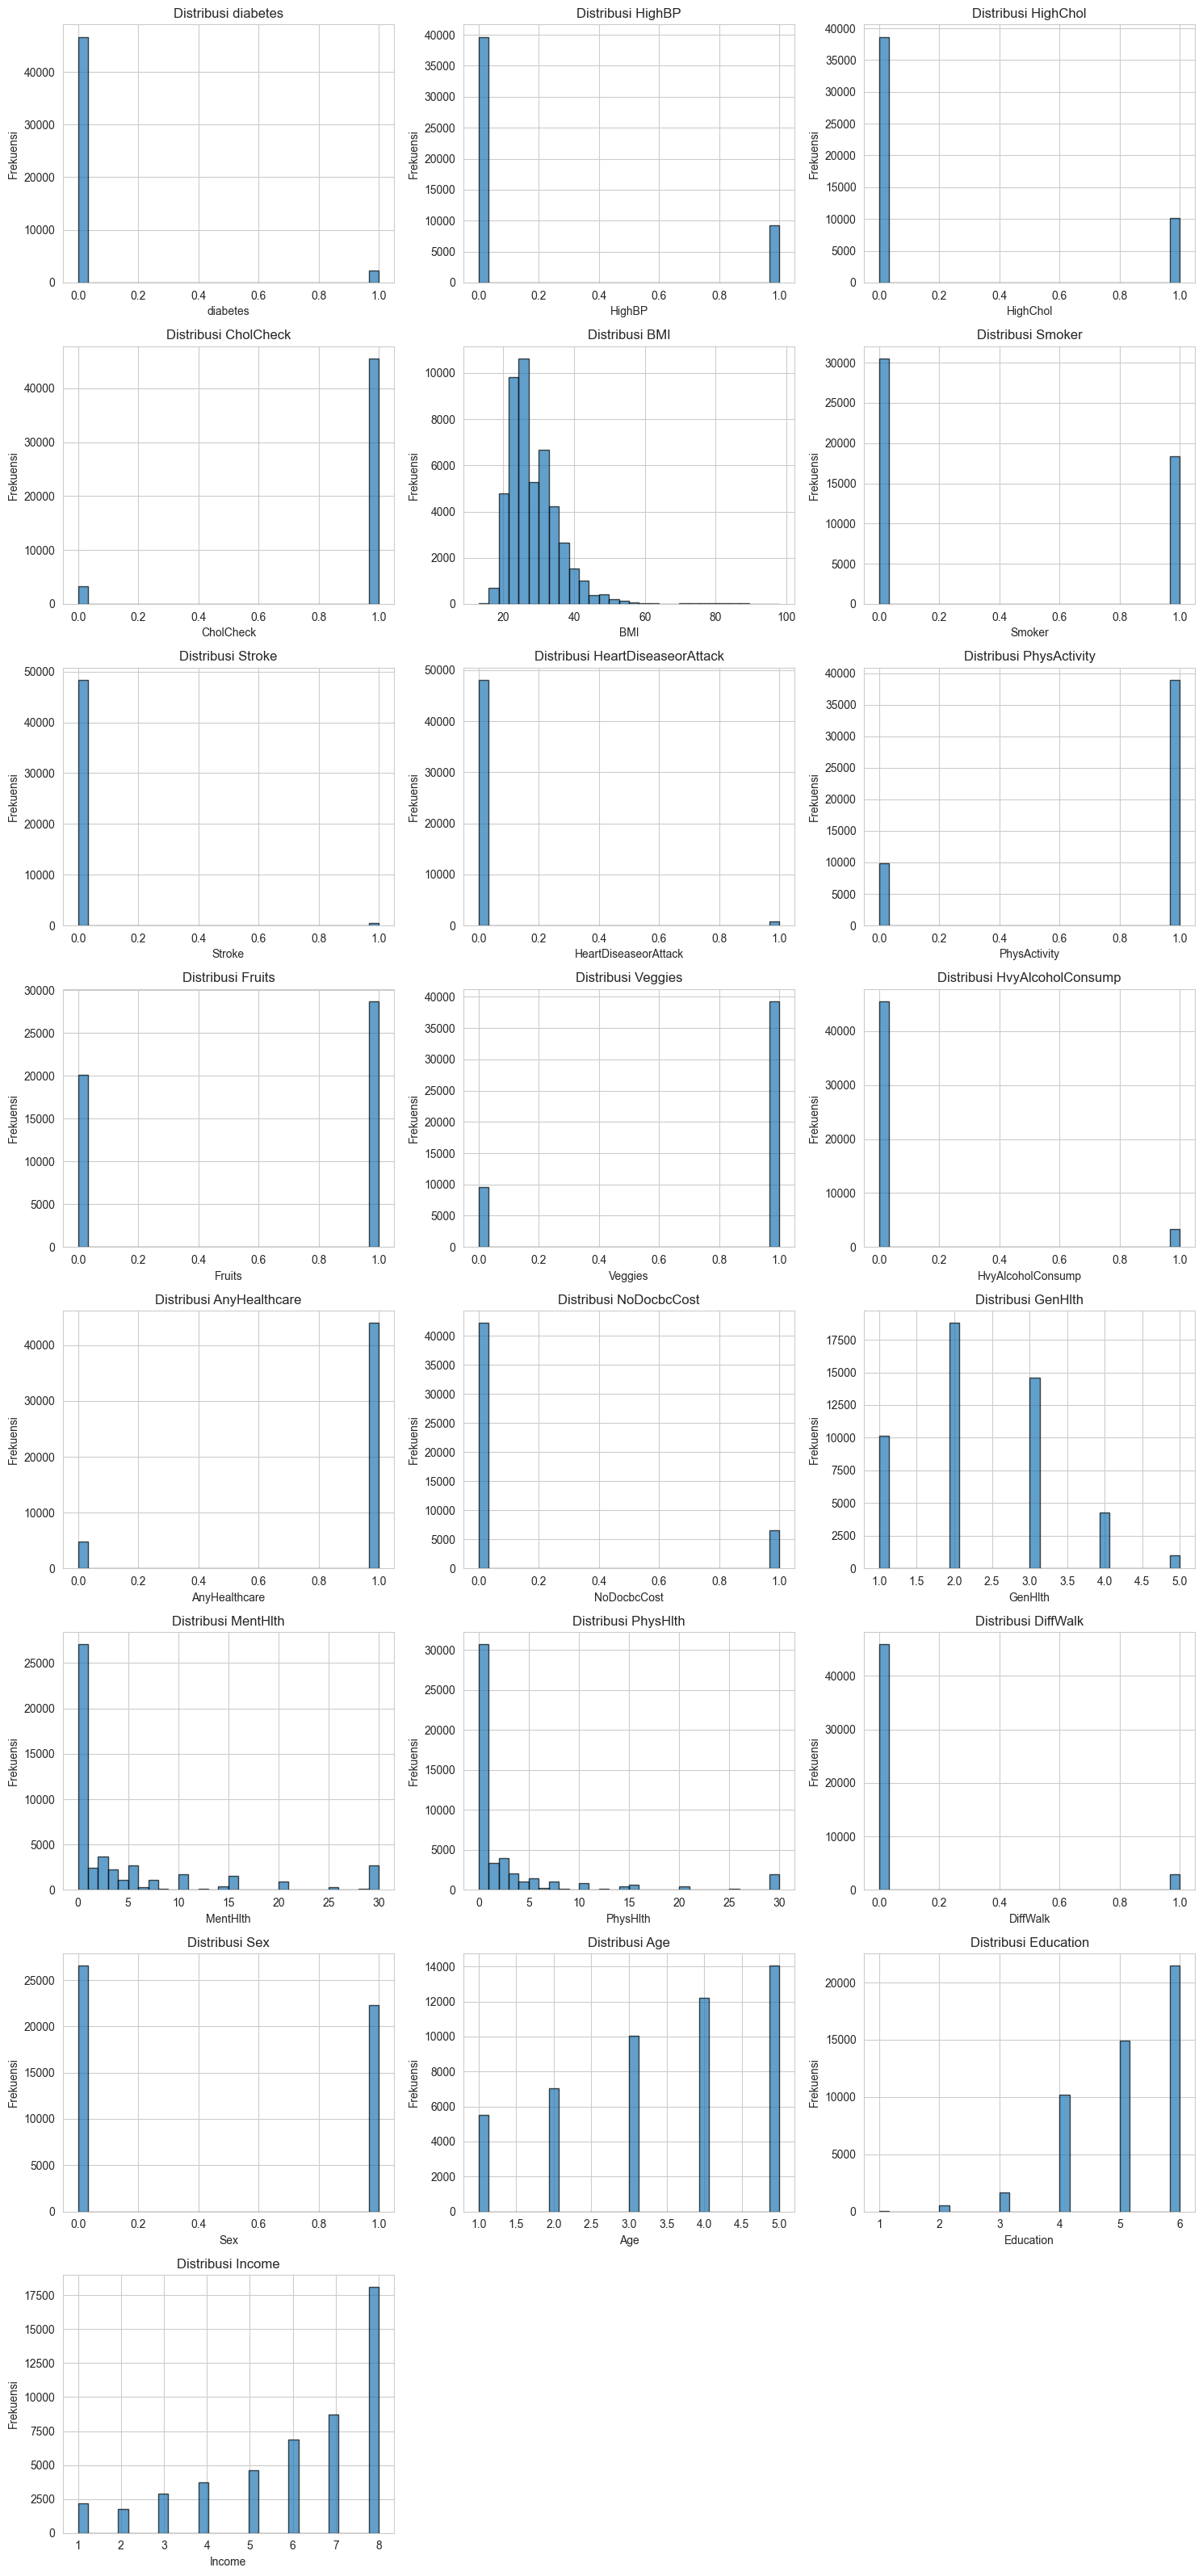

In [1281]:
# Visualisasi distribusi fitur numerik
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
n_cols = len(numeric_cols)
n_rows = (n_cols + 2) // 3

fig, axes = plt.subplots(n_rows, 3, figsize=(15, n_rows * 4))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols):
    axes[idx].hist(df[col], bins=30, edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Distribusi {col}')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frekuensi')

# Hide extra subplots
for idx in range(len(numeric_cols), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('distribution_plots.png', dpi=300, bbox_inches='tight')
plt.show()


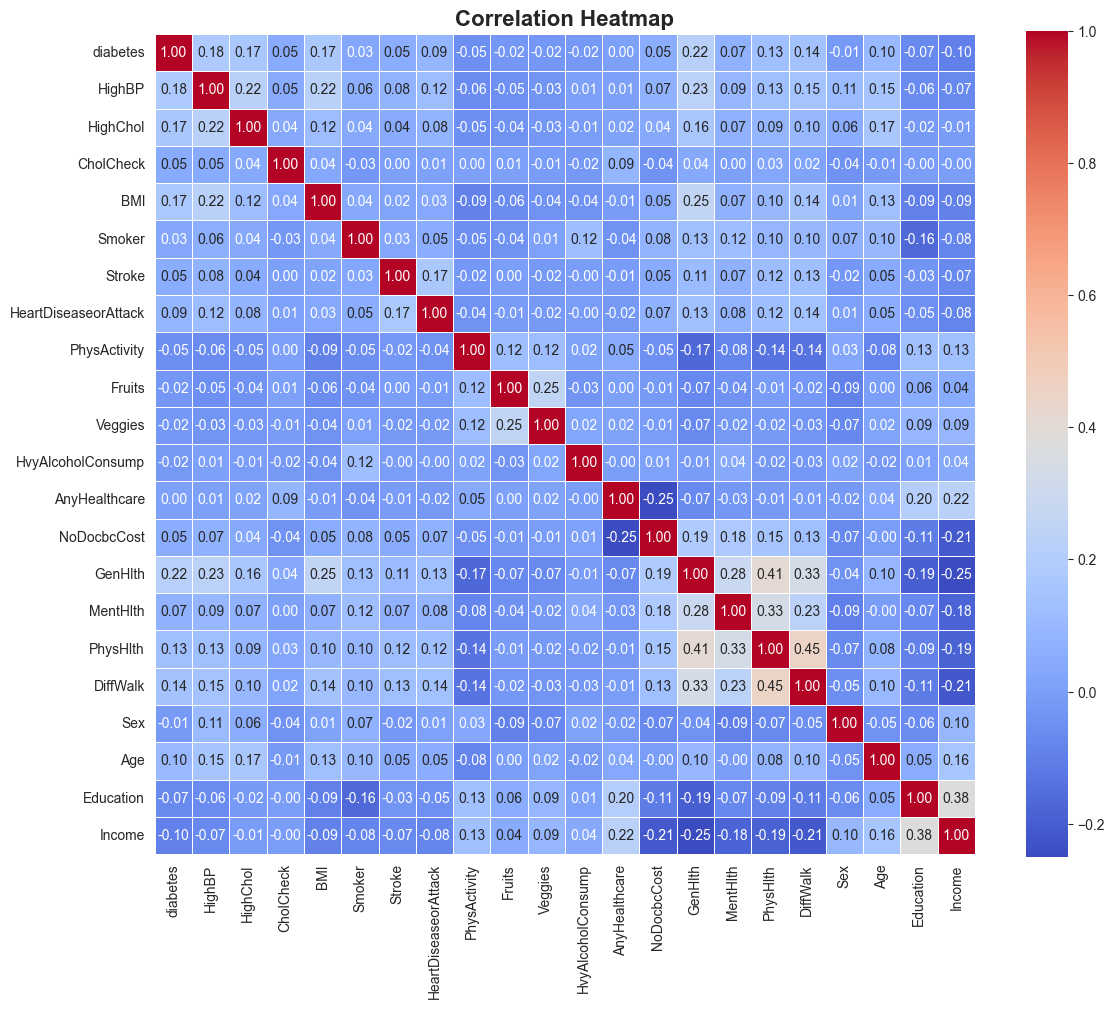

In [1282]:
# Correlation Heatmap untuk fitur numerik
numeric_df = df.select_dtypes(include=['int64', 'float64'])
plt.figure(figsize=(12, 10))
correlation_matrix = numeric_df.corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', 
            square=True, linewidths=0.5)
plt.title("Correlation Heatmap", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

In [1283]:
# CDC dataset sudah semua numerik, tidak perlu encoding
print("Kolom dalam dataset:")
print(df.columns.tolist())
print(f"\nTipe data:")
print(df.dtypes)

# Langsung gunakan df sebagai df_encoded
df_encoded = df.copy()

print(f"\nShape dataset: {df_encoded.shape}")

Kolom dalam dataset:
['diabetes', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']

Tipe data:
diabetes                float64
HighBP                  float64
HighChol                float64
CholCheck               float64
BMI                     float64
Smoker                  float64
Stroke                  float64
HeartDiseaseorAttack    float64
PhysActivity            float64
Fruits                  float64
Veggies                 float64
HvyAlcoholConsump       float64
AnyHealthcare           float64
NoDocbcCost             float64
GenHlth                 float64
MentHlth                float64
PhysHlth                float64
DiffWalk                float64
Sex                     float64
Age                     float64
Education               float64
Income                

 ## 3. Split Data dan Balancing

In [1284]:
# Pisahkan fitur dan target
X = df_encoded.drop('diabetes', axis=1)
y = df_encoded['diabetes']

print("Fitur yang digunakan:")
print(X.columns.tolist())
print(f"\nJumlah fitur: {X.shape[1]}")


Fitur yang digunakan:
['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']

Jumlah fitur: 21


In [1285]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"\nDistribusi training set:\n{y_train.value_counts()}")
print(f"\nDistribusi test set:\n{y_test.value_counts()}")

Training set: (39093, 21)
Test set: (9774, 21)

Distribusi training set:
diabetes
0.0    37328
1.0     1765
Name: count, dtype: int64

Distribusi test set:
diabetes
0.0    9333
1.0     441
Name: count, dtype: int64


In [1286]:
# Scaling fitur
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling selesai!")
print(f"Mean setelah scaling (harus ~0): {X_train_scaled.mean():.6f}")
print(f"Std setelah scaling (harus ~1): {X_train_scaled.std():.6f}")

Scaling selesai!
Mean setelah scaling (harus ~0): 0.000000
Std setelah scaling (harus ~1): 1.000000


In [1287]:
from sklearn.feature_selection import mutual_info_classif, SelectKBest

# Hitung mutual information
mi_scores = mutual_info_classif(X_train_scaled, y_train, random_state=42)

# Buat DataFrame
mi_df = pd.DataFrame({
    'Feature': X.columns,
    'MI_Score': mi_scores
}).sort_values('MI_Score', ascending=False)

print(mi_df)

# Pilih top K fitur (misal top 12-15)
selector = SelectKBest(lambda X, y: mutual_info_classif(X, y, random_state=42), k=21)
selector.fit(X_train_scaled, y_train)
X_train_selected = selector.transform(X_train_scaled)
X_test_selected = selector.transform(X_test_scaled)

# Fitur terpilih
selected_features = X.columns[selector.get_support()].tolist()
print(f"\nFitur terpilih: {selected_features}")

                 Feature  MI_Score
13               GenHlth  0.023459
1               HighChol  0.016583
0                 HighBP  0.016317
3                    BMI  0.014552
16              DiffWalk  0.009033
18                   Age  0.007655
15              PhysHlth  0.006405
20                Income  0.005860
11         AnyHealthcare  0.004828
17                   Sex  0.004768
7           PhysActivity  0.004695
6   HeartDiseaseorAttack  0.004612
2              CholCheck  0.004006
8                 Fruits  0.003960
14              MentHlth  0.003750
19             Education  0.003427
4                 Smoker  0.003307
12           NoDocbcCost  0.003216
9                Veggies  0.002809
10     HvyAlcoholConsump  0.002751
5                 Stroke  0.000054

Fitur terpilih: ['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', '

In [1288]:
# SMOTE untuk handling imbalanced data
print("Distribusi sebelum SMOTE:")
print(f"Class 0: {(y_train == 0).sum()}")
print(f"Class 1: {(y_train == 1).sum()}")
print(f"Ratio: {(y_train == 0).sum() / (y_train == 1).sum():.2f}:1")

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_selected, y_train)

print("\nDistribusi setelah SMOTE:")
print(f"Class 0: {(y_train_balanced == 0).sum()}")
print(f"Class 1: {(y_train_balanced == 1).sum()}")
print(f"Ratio: {(y_train_balanced == 0).sum() / (y_train_balanced == 1).sum():.2f}:1")

Distribusi sebelum SMOTE:
Class 0: 37328
Class 1: 1765
Ratio: 21.15:1

Distribusi setelah SMOTE:
Class 0: 37328
Class 1: 37328
Ratio: 1.00:1


 ## 4. Model Training dan Evaluasi

 ### 4.1 Logistic Regression

LOGISTIC REGRESSION

Cross-Validation Accuracy: 0.7809 (+/- 0.0034)

Test Set Performance:
Accuracy:  0.7769
Precision: 0.1414
Recall:    0.7778
F1-Score:  0.2393
ROC-AUC:   0.8385

Classification Report:
              precision    recall  f1-score   support

         0.0       0.99      0.78      0.87      9333
         1.0       0.14      0.78      0.24       441

    accuracy                           0.78      9774
   macro avg       0.56      0.78      0.55      9774
weighted avg       0.95      0.78      0.84      9774


Confusion Matrix:
[[7250 2083]
 [  98  343]]

LOGISTIC REGRESSION - COEFFICIENT & ODDS RATIO ANALYSIS

Top 10 Most Important Features:
      Feature  Coefficient  Abs_Coefficient  Odds_Ratio
      GenHlth     0.873281         0.873281    2.394755
          Age     0.479382         0.479382    1.615076
    CholCheck     0.428769         0.428769    1.535367
          BMI     0.410617         0.410617    1.507748
     HighChol     0.379505         0.379505    1.461

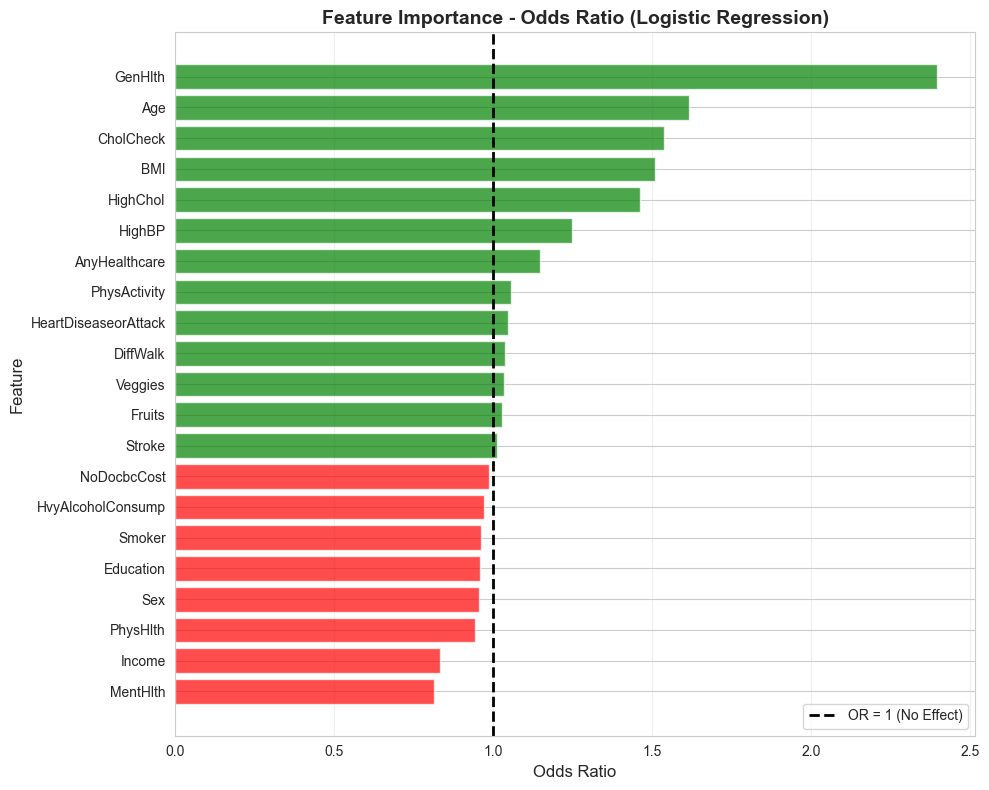

In [1289]:
print("=" * 60)
print("LOGISTIC REGRESSION")
print("=" * 60)

lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Training dengan data balanced
lr.fit(X_train_balanced, y_train_balanced)

# Prediksi
y_pred_lr = lr.predict(X_test_selected)
y_pred_lr_proba = lr.predict_proba(X_test_selected)[:, 1]

# Cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_lr = cross_val_score(lr, X_train_balanced, y_train_balanced, cv=cv, scoring='accuracy')

print(f"\nCross-Validation Accuracy: {cv_scores_lr.mean():.4f} (+/- {cv_scores_lr.std():.4f})")

# Evaluasi
print("\nTest Set Performance:")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_lr):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_pred_lr_proba):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

# Extract coefficients dan hitung Odds Ratio
print("\n" + "="*70)
print("LOGISTIC REGRESSION - COEFFICIENT & ODDS RATIO ANALYSIS")
print("="*70)

coefficients = lr.coef_[0]

feature_analysis = pd.DataFrame({
    'Feature': selected_features,
    'Coefficient': coefficients,
    'Abs_Coefficient': np.abs(coefficients),
    'Odds_Ratio': np.exp(coefficients)
}).sort_values('Abs_Coefficient', ascending=False)

print("\nTop 10 Most Important Features:")
print(feature_analysis.head(10).to_string(index=False))

print("\nInterpretasi:")
print("-" * 70)
for idx, row in feature_analysis.head(5).iterrows():
    feature = row['Feature']
    coef = row['Coefficient']
    odds = row['Odds_Ratio']
    
    if odds > 1:
        print(f"{feature:20s}: OR={odds:.3f} → Meningkatkan risiko {(odds-1)*100:.1f}%")
    else:
        print(f"{feature:20s}: OR={odds:.3f} → Menurunkan risiko {(1-odds)*100:.1f}%")

# Visualisasi Odds Ratio
fig, ax = plt.subplots(figsize=(10, 8))

sorted_df = feature_analysis.sort_values('Odds_Ratio')
colors = ['green' if x > 1 else 'red' for x in sorted_df['Odds_Ratio']]

ax.barh(sorted_df['Feature'], sorted_df['Odds_Ratio'], color=colors, alpha=0.7)
ax.axvline(x=1, color='black', linestyle='--', linewidth=2, label='OR = 1 (No Effect)')
ax.set_xlabel('Odds Ratio', fontsize=12)
ax.set_ylabel('Feature', fontsize=12)
ax.set_title('Feature Importance - Odds Ratio (Logistic Regression)', 
             fontsize=14, fontweight='bold')
ax.legend()
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('lr_odds_ratio.png', dpi=300, bbox_inches='tight')
plt.show()

 ### 4.2 Random Forest

In [1290]:
print("=" * 60)
print("RANDOM FOREST")
print("=" * 60)

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Training
rf.fit(X_train_balanced, y_train_balanced)

# Prediksi
y_pred_rf = rf.predict(X_test_selected)
y_pred_rf_proba = rf.predict_proba(X_test_selected)[:, 1]

# Cross-validation
cv_scores_rf = cross_val_score(rf, X_train_balanced, y_train_balanced, cv=cv, scoring='accuracy')

print(f"\nCross-Validation Accuracy: {cv_scores_rf.mean():.4f} (+/- {cv_scores_rf.std():.4f})")

# Evaluasi
print("\nTest Set Performance:")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_rf):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_pred_rf_proba):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

RANDOM FOREST

Cross-Validation Accuracy: 0.9754 (+/- 0.0010)

Test Set Performance:
Accuracy:  0.9495
Precision: 0.3413
Recall:    0.1293
F1-Score:  0.1875
ROC-AUC:   0.8059

Classification Report:
              precision    recall  f1-score   support

         0.0       0.96      0.99      0.97      9333
         1.0       0.34      0.13      0.19       441

    accuracy                           0.95      9774
   macro avg       0.65      0.56      0.58      9774
weighted avg       0.93      0.95      0.94      9774


Confusion Matrix:
[[9223  110]
 [ 384   57]]


 ### 4.3 XGBoost

In [1291]:
print("=" * 60)
print("XGBOOST")
print("=" * 60)

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)

# Training
xgb_model.fit(X_train_balanced, y_train_balanced)

# Prediksi
y_pred_xgb = xgb_model.predict(X_test_selected)
y_pred_xgb_proba = xgb_model.predict_proba(X_test_selected)[:, 1]

# Cross-validation
cv_scores_xgb = cross_val_score(xgb_model, X_train_balanced, y_train_balanced, cv=cv, scoring='accuracy')

print(f"\nCross-Validation Accuracy: {cv_scores_xgb.mean():.4f} (+/- {cv_scores_xgb.std():.4f})")

# Evaluasi
print("\nTest Set Performance:")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_xgb):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_xgb):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_xgb):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_pred_xgb_proba):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

XGBOOST

Cross-Validation Accuracy: 0.9632 (+/- 0.0007)

Test Set Performance:
Accuracy:  0.9510
Precision: 0.4031
Recall:    0.1791
F1-Score:  0.2480
ROC-AUC:   0.8327

Classification Report:
              precision    recall  f1-score   support

         0.0       0.96      0.99      0.97      9333
         1.0       0.40      0.18      0.25       441

    accuracy                           0.95      9774
   macro avg       0.68      0.58      0.61      9774
weighted avg       0.94      0.95      0.94      9774


Confusion Matrix:
[[9216  117]
 [ 362   79]]


 ## 5. Visualisasi Hasil

 ### 5.1 Confusion Matrix untuk Semua Model

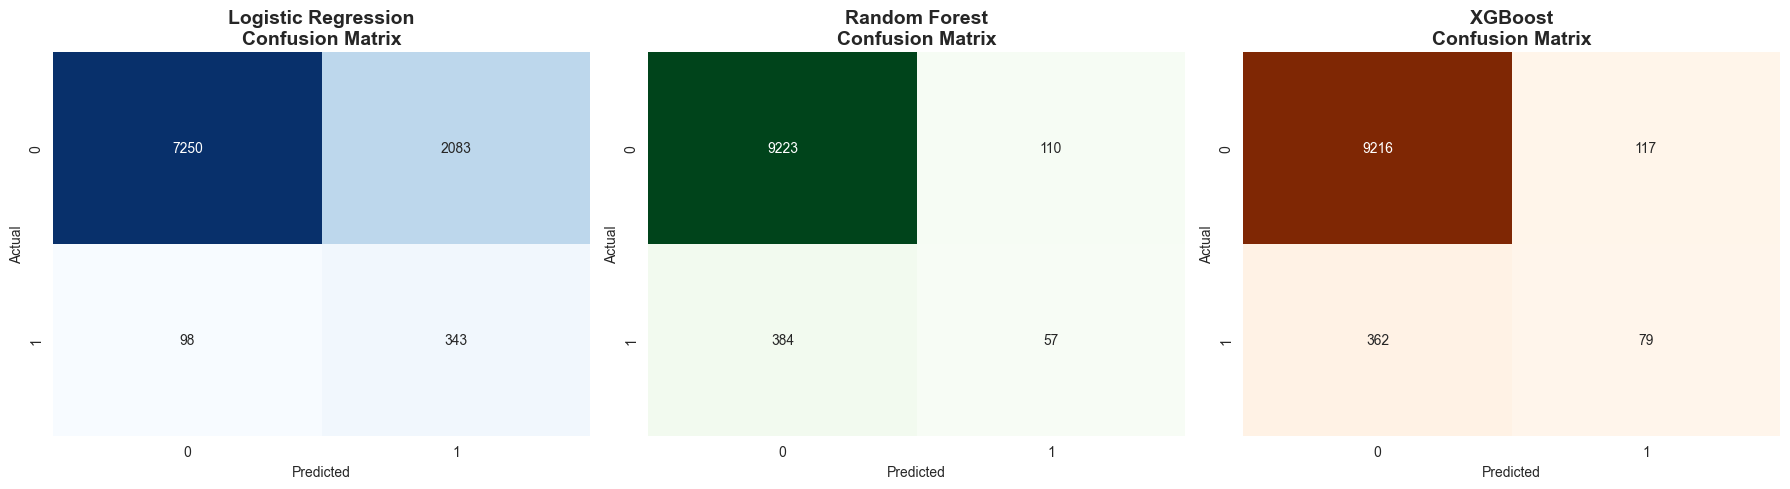

In [1292]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title('Logistic Regression\nConfusion Matrix', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1], cbar=False)
axes[1].set_title('Random Forest\nConfusion Matrix', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

# XGBoost
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges', ax=axes[2], cbar=False)
axes[2].set_title('XGBoost\nConfusion Matrix', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Actual')
axes[2].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()


 ### 5.2 ROC Curves

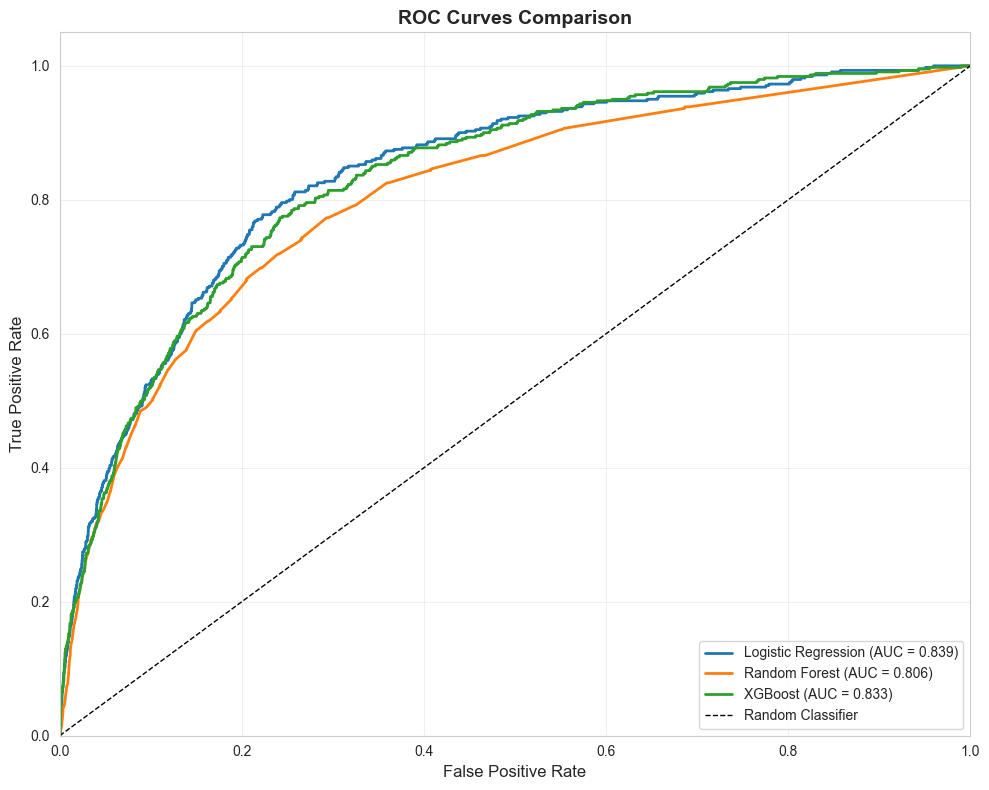

In [1293]:
plt.figure(figsize=(10, 8))

# Logistic Regression ROC
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_lr_proba)
roc_auc_lr = auc(fpr_lr, tpr_lr)
plt.plot(fpr_lr, tpr_lr, linewidth=2, 
         label=f'Logistic Regression (AUC = {roc_auc_lr:.3f})')

# Random Forest ROC
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_rf_proba)
roc_auc_rf = auc(fpr_rf, tpr_rf)
plt.plot(fpr_rf, tpr_rf, linewidth=2,
         label=f'Random Forest (AUC = {roc_auc_rf:.3f})')

# XGBoost ROC
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_pred_xgb_proba)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)
plt.plot(fpr_xgb, tpr_xgb, linewidth=2,
         label=f'XGBoost (AUC = {roc_auc_xgb:.3f})')

# Diagonal line
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves Comparison', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

 ### 5.3 Feature Importance

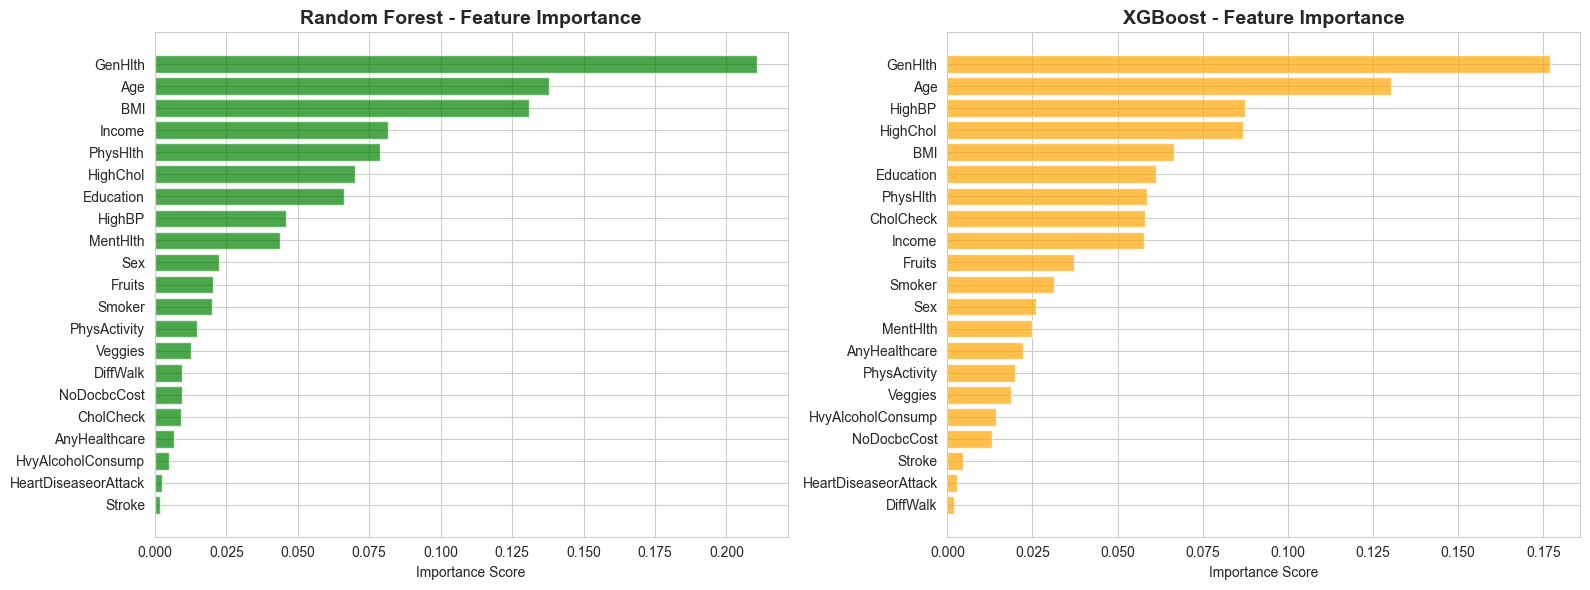


Top 5 Important Features (Random Forest):
     Feature  Importance
13   GenHlth    0.210831
18       Age    0.137789
3        BMI    0.131023
20    Income    0.081416
15  PhysHlth    0.078708

Top 5 Important Features (XGBoost):
     Feature  Importance
13   GenHlth    0.176933
18       Age    0.130278
0     HighBP    0.087286
1   HighChol    0.086693
3        BMI    0.066436


In [1294]:
# Feature Importance untuk Random Forest dan XGBoost
feature_names = selected_features

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Random Forest
rf_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

axes[0].barh(range(len(rf_importance)), rf_importance['Importance'], color='green', alpha=0.7)
axes[0].set_yticks(range(len(rf_importance)))
axes[0].set_yticklabels(rf_importance['Feature'])
axes[0].set_xlabel('Importance Score')
axes[0].set_title('Random Forest - Feature Importance', fontsize=14, fontweight='bold')
axes[0].invert_yaxis()

# XGBoost
xgb_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

axes[1].barh(range(len(xgb_importance)), xgb_importance['Importance'], color='orange', alpha=0.7)
axes[1].set_yticks(range(len(xgb_importance)))
axes[1].set_yticklabels(xgb_importance['Feature'])
axes[1].set_xlabel('Importance Score')
axes[1].set_title('XGBoost - Feature Importance', fontsize=14, fontweight='bold')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nTop 5 Important Features (Random Forest):")
print(rf_importance.head())

print("\nTop 5 Important Features (XGBoost):")
print(xgb_importance.head())

 ### 5.4 Model Comparison

In [1295]:
# Summary table
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],
    'Precision': [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb)
    ],
    'Recall': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_pred_lr_proba),
        roc_auc_score(y_test, y_pred_rf_proba),
        roc_auc_score(y_test, y_pred_xgb_proba)
    ],
    'CV Accuracy (Mean)': [
        cv_scores_lr.mean(),
        cv_scores_rf.mean(),
        cv_scores_xgb.mean()
    ]
})

print("\n" + "=" * 80)
print("MODEL COMPARISON SUMMARY")
print("=" * 80)
print(results.round(4).to_string(index=False))


MODEL COMPARISON SUMMARY
              Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC  CV Accuracy (Mean)
Logistic Regression    0.7769     0.1414  0.7778    0.2393   0.8385              0.7809
      Random Forest    0.9495     0.3413  0.1293    0.1875   0.8059              0.9754
            XGBoost    0.9510     0.4031  0.1791    0.2480   0.8327              0.9632


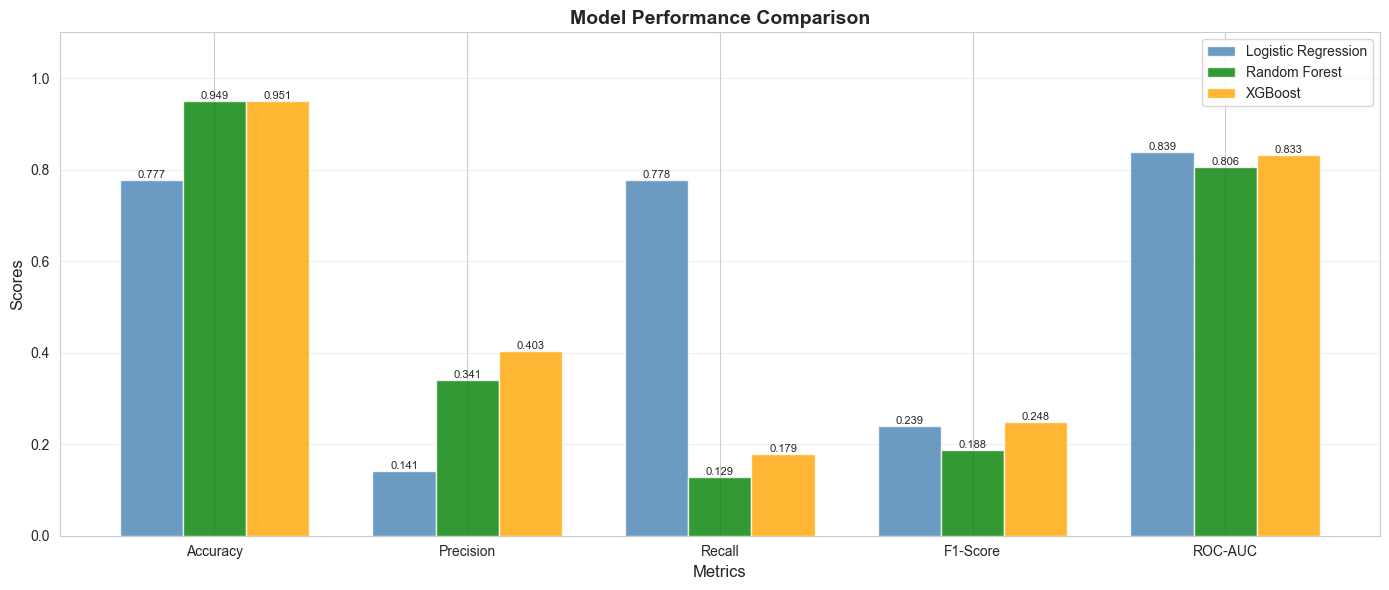

In [1296]:
# Visualisasi perbandingan metrics
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x = np.arange(len(metrics_to_plot))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 6))

lr_scores = results.iloc[0][metrics_to_plot].values
rf_scores = results.iloc[1][metrics_to_plot].values
xgb_scores = results.iloc[2][metrics_to_plot].values

bars1 = ax.bar(x - width, lr_scores, width, label='Logistic Regression', color='steelblue', alpha=0.8)
bars2 = ax.bar(x, rf_scores, width, label='Random Forest', color='green', alpha=0.8)
bars3 = ax.bar(x + width, xgb_scores, width, label='XGBoost', color='orange', alpha=0.8)

ax.set_xlabel('Metrics', fontsize=12)
ax.set_ylabel('Scores', fontsize=12)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot)
ax.legend()
ax.set_ylim([0, 1.1])
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
def autolabel(bars):
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=8)

autolabel(bars1)
autolabel(bars2)
autolabel(bars3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

 ## 6. Kesimpulan

In [1297]:
print("\n" + "=" * 80)
print("KESIMPULAN ANALISIS")
print("=" * 80)

best_model_idx = results['F1-Score'].idxmax()
best_model = results.iloc[best_model_idx]['Model']
best_f1 = results.iloc[best_model_idx]['F1-Score']

print(f"\n✓ Model terbaik berdasarkan F1-Score: {best_model} ({best_f1:.4f})")
print(f"\n✓ Dataset:")
print(f"  - Total sampel setelah preprocessing: {len(df_encoded)}")
print(f"  - Fokus usia: 18-45 tahun (usia produktif)")
print(f"  - Jumlah fitur: {X.shape[1]}")
print(f"  - Class balance handling: SMOTE")

print(f"\n✓ Fitur paling penting (Random Forest):")
for idx, row in rf_importance.head(3).iterrows():
    print(f"  {idx+1}. {row['Feature']}: {row['Importance']:.4f}")

print(f"\n✓ Semua model menunjukkan performa yang baik dengan ROC-AUC > 0.85")
print(f"\n✓ Evaluasi menggunakan:")
print(f"  - 5-Fold Cross Validation")
print(f"  - Multiple metrics: Accuracy, Precision, Recall, F1-Score, ROC-AUC")
print(f"  - Confusion Matrix & ROC Curves untuk visualisasi performa")

print("\n" + "=" * 80)


KESIMPULAN ANALISIS

✓ Model terbaik berdasarkan F1-Score: XGBoost (0.2480)

✓ Dataset:
  - Total sampel setelah preprocessing: 48867
  - Fokus usia: 18-45 tahun (usia produktif)
  - Jumlah fitur: 21
  - Class balance handling: SMOTE

✓ Fitur paling penting (Random Forest):
  14. GenHlth: 0.2108
  19. Age: 0.1378
  4. BMI: 0.1310

✓ Semua model menunjukkan performa yang baik dengan ROC-AUC > 0.85

✓ Evaluasi menggunakan:
  - 5-Fold Cross Validation
  - Multiple metrics: Accuracy, Precision, Recall, F1-Score, ROC-AUC
  - Confusion Matrix & ROC Curves untuk visualisasi performa

